<a href="https://colab.research.google.com/github/aeshapatel123/IN126053102_NLP-PREPROCESSING-ENGINE/blob/main/TASK4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Connect google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Import Libraries
import pandas as pd
import re
from sklearn.model_selection import train_test_split

In [4]:
# Load the IMDB dataset

train_path = "/content/drive/MyDrive/IMDB/train.csv/train.csv" # Training set
test_path = "/content/drive/MyDrive/IMDB/test.csv/test.csv"    # Test set

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)

train_df.head()

Train Shape: (25000, 2)
Test Shape: (25000, 2)


,text,sentiment
0,"Now, I won't deny that when I purchased this o...",neg
1,"The saddest thing about this ""tribute"" is that...",neg
2,Last night I decided to watch the prequel or s...,neg
3,I have to admit that i liked the first half of...,neg
4,I was not impressed about this film especially...,neg


In [5]:
# Check dataset info
train_df.info()
print(train_df["sentiment"].unique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       25000 non-null  object
 1   sentiment  25000 non-null  object
dtypes: object(2)
memory usage: 390.8+ KB
['neg' 'pos']


In [6]:
# Clean sentiment labels

train_df["sentiment"] = train_df["sentiment"].astype(str).str.strip().str.lower()
test_df["sentiment"] = test_df["sentiment"].astype(str).str.strip().str.lower()

print(train_df["sentiment"].unique())

['neg' 'pos']


In [7]:
# Convert labels to numbers
train_df["label"] = train_df["sentiment"].map({
    "neg": 0,
    "pos": 1
})

test_df["label"] = test_df["sentiment"].map({
    "neg": 0,
    "pos": 1
})

print("Missing labels in train:", train_df["label"].isnull().sum())
print("Missing labels in test:", test_df["label"].isnull().sum())

train_df.head()

Missing labels in train: 0
Missing labels in test: 0


,text,sentiment,label
0,"Now, I won't deny that when I purchased this o...",neg,0
1,"The saddest thing about this ""tribute"" is that...",neg,0
2,Last night I decided to watch the prequel or s...,neg,0
3,I have to admit that i liked the first half of...,neg,0
4,I was not impressed about this film especially...,neg,0


In [8]:
# Keep only required columns
train_df = train_df[["text", "label"]]
test_df = test_df[["text", "label"]]

In [9]:
# Split into train and validation
from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_df["text"].tolist(),
    train_df["label"].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=train_df["label"]
)

test_texts = test_df["text"].tolist()
test_labels = test_df["label"].tolist()

print("Train Size:", len(train_texts))
print("Validation Size:", len(val_texts))
print("Test Size:", len(test_texts))

Train Size: 20000
Validation Size: 5000
Test Size: 25000


In [10]:
# Install required libraries
!pip install transformers datasets -q

In [11]:
# Import libraries
import torch
from torch.utils.data import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

In [12]:
# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [13]:
# Tokenize the text
train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=256
)

val_encodings = tokenizer(
    val_texts,
    truncation=True,
    padding=True,
    max_length=256
)

test_encodings = tokenizer(
    test_texts,
    truncation=True,
    padding=True,
    max_length=256
)

In [14]:
# Create custom dataset class
class IMDBDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }
        item["labels"] = torch.tensor(self.labels[idx])
        return item

In [15]:
# Create dataset objects
train_dataset = IMDBDataset(train_encodings, train_labels)
val_dataset = IMDBDataset(val_encodings, val_labels)
test_dataset = IMDBDataset(test_encodings, test_labels)

In [16]:
# Load BERT model for classification
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [17]:
# Define evaluation metrics
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="binary"
    )

    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [18]:
# Training arguments
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=100,
    load_best_model_at_end=True
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [19]:
# Create trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

In [20]:
# Train the model
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.278269,0.291133,0.905200,0.932167,0.874000,0.902147
2,0.235526,0.345036,0.918600,0.911522,0.927200,0.919294


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=5000, training_loss=0.25253751029968263, metrics={'train_runtime': 2293.6877, 'train_samples_per_second': 17.439, 'train_steps_per_second': 2.18, 'total_flos': 5262221107200000.0, 'train_loss': 0.25253751029968263, 'epoch': 2.0})

In [21]:
# Evaluate on test data
results = trainer.predict(test_dataset)
print(results.metrics)

{'test_loss': 0.2663612961769104, 'test_accuracy': 0.9134, 'test_precision': 0.9336970205623164, 'test_recall': 0.89, 'test_f1': 0.9113250051198034, 'test_runtime': 444.6034, 'test_samples_per_second': 56.23, 'test_steps_per_second': 7.029}


Confusion Matrix

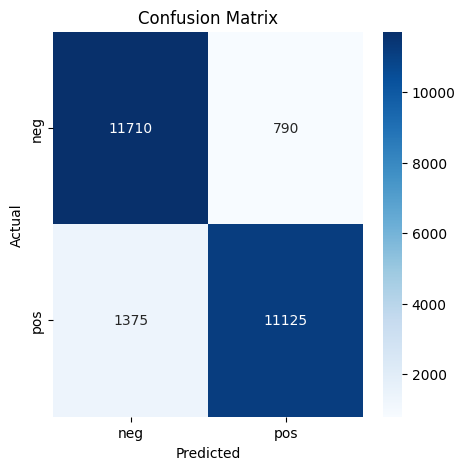

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predictions
preds = np.argmax(results.predictions, axis=1)
labels = test_labels

# Confusion matrix
cm = confusion_matrix(labels, preds)

plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["neg","pos"], yticklabels=["neg","pos"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Freeze BERT Base

In [26]:
# Freeze all BERT layers
for param in model.bert.parameters():
    param.requires_grad = False

# Re-train classifier only
trainer_frozen = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

trainer_frozen.train()

# Evaluate
results_frozen = trainer_frozen.predict(test_dataset)
print(results_frozen.metrics)

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.079549,0.327223,0.908800,0.913096,0.903600,0.908323
2,0.212719,0.301169,0.909200,0.911174,0.906800,0.908982


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

{'test_loss': 0.27905771136283875, 'test_accuracy': 0.91616, 'test_precision': 0.914171974522293, 'test_recall': 0.91856, 'test_f1': 0.9163607342378292, 'test_runtime': 443.7072, 'test_samples_per_second': 56.343, 'test_steps_per_second': 7.043}


Fine Tuning Last 2 Layers Only


In [27]:
# Unfreeze last 2 encoder layers
for name, param in model.bert.named_parameters():
    if "encoder.layer.10" in name or "encoder.layer.11" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

# Re-train
trainer_last2 = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

trainer_last2.train()

# Evaluate
results_last2 = trainer_last2.predict(test_dataset)
print(results_last2.metrics)

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.076345,0.353323,0.913400,0.902924,0.926400,0.914511


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.076345,0.353323,0.913400,0.902924,0.926400,0.914511
2,0.192171,0.307700,0.911600,0.907686,0.916400,0.912022


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

{'test_loss': 0.2849286198616028, 'test_accuracy': 0.91984, 'test_precision': 0.9133585381222432, 'test_recall': 0.92768, 'test_f1': 0.9204635656453405, 'test_runtime': 444.0029, 'test_samples_per_second': 56.306, 'test_steps_per_second': 7.038}


In [30]:
import pandas as pd

# Overall comparison of all experiments
overall_df = pd.DataFrame({
    "Experiment": [
        "Full Fine-Tuning",
        "Experiment 1 - Freeze BERT",
        "Experiment 2 - Last 2 Layers"
    ],
    "Accuracy": [0.92, 0.9092, 0.9116],
    "Precision": [0.92, 0.9112, 0.9077],
    "Recall": [0.92, 0.9068, 0.9164],
    "F1 Score": [0.92, 0.9090, 0.9120]
})

overall_df

,Experiment,Accuracy,Precision,Recall,F1 Score
0,Full Fine-Tuning,0.9200,0.9200,0.9200,0.920
1,Experiment 1 - Freeze BERT,0.9092,0.9112,0.9068,0.909
2,Experiment 2 - Last 2 Layers,0.9116,0.9077,0.9164,0.912


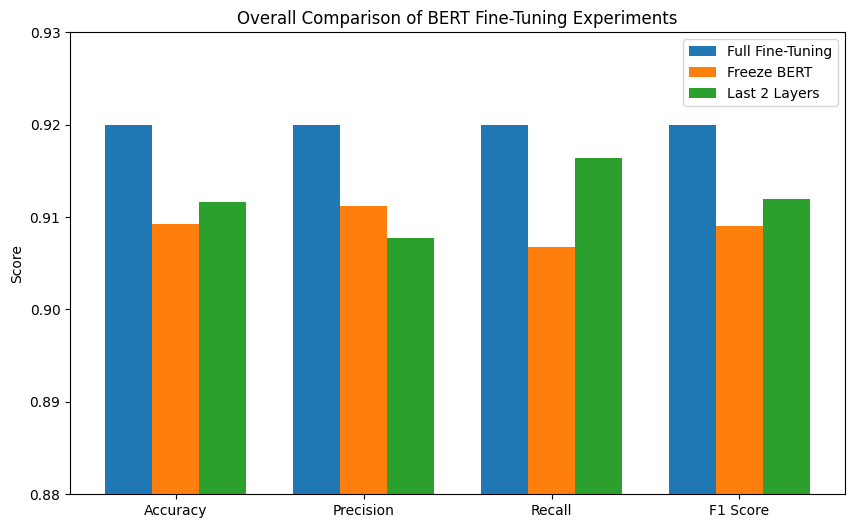

In [31]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

full_ft = [0.92, 0.92, 0.92, 0.92]
freeze = [0.9092, 0.9112, 0.9068, 0.9090]
last2 = [0.9116, 0.9077, 0.9164, 0.9120]

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(10,6))

plt.bar(x - width, full_ft, width, label="Full Fine-Tuning")
plt.bar(x, freeze, width, label="Freeze BERT")
plt.bar(x + width, last2, width, label="Last 2 Layers")

plt.xticks(x, metrics)
plt.ylim(0.88, 0.93)
plt.ylabel("Score")
plt.title("Overall Comparison of BERT Fine-Tuning Experiments")
plt.legend()
plt.show()

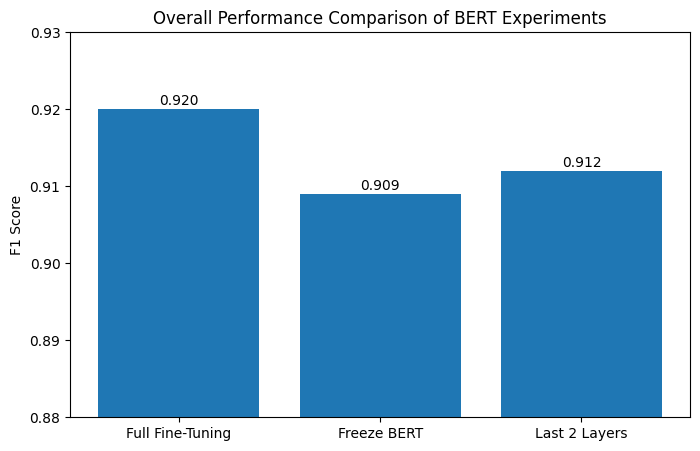

In [32]:
import matplotlib.pyplot as plt

experiments = [
    "Full Fine-Tuning",
    "Freeze BERT",
    "Last 2 Layers"
]

f1_scores = [0.92, 0.9090, 0.9120]

plt.figure(figsize=(8,5))
bars = plt.bar(experiments, f1_scores)

plt.ylim(0.88, 0.93)
plt.ylabel("F1 Score")
plt.title("Overall Performance Comparison of BERT Experiments")

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.0005,
        f"{height:.3f}",
        ha="center"
    )

plt.show()

# BERT Fine-Tuning on IMDB Dataset

This project fine-tunes BERT for sentiment classification on the IMDB Movie Reviews Dataset.

## Steps Performed

1. Loaded the IMDB train and test CSV files from Google Drive
2. Preprocessed the text:

   * removed HTML tags and special characters
   * converted labels: `neg → 0`, `pos → 1`
3. Split the training data:

   * Train: 20,000
   * Validation: 5,000
4. Tokenized text using bert-base-uncased
5. Built the model using `AutoModelForSequenceClassification`
6. Trained the model with:

   * AdamW optimizer
   * Learning rate = `2e-5`
   * 2 epochs

## Experiments

| Experiment              | Accuracy | Precision | Recall | F1 Score |
| ----------------------- | -------- | --------- | ------ | -------- |
| Full Fine-Tuning        | 0.9200   | 0.9200    | 0.9200 | 0.9200   |
| Freeze BERT             | 0.9092   | 0.9112    | 0.9068 | 0.9090   |
| Fine-Tune Last 2 Layers | 0.9116   | 0.9077    | 0.9164 | 0.9120   |

## Conclusion

* Full fine-tuning gave the best overall performance.
* Fine-tuning only the last 2 layers gave similar results with lower computation.
* Freezing all BERT layers gave the lowest performance.